# Time Series Forecasting: SVR vs ARIMA
**Mini Project Kelompok 3**

## Objektif
Studi ini bertujuan untuk membandingkan performa *forecasting* antara model **Support Vector Regression (SVR)** dan **ARIMA** pada data deret waktu curah hujan dan jumlah kasus. Evaluasi difokuskan pada akurasi prediksi (RMSE, MAE, R2) dan kesesuaian model.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller

# Konfigurasi
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

DATA_PATH = "Data-TimeSeries.xlsx"
TRAIN_END_DATE = '2020-12-31'
TEST_START_DATE = '2021-01-01'
TEST_END_DATE = '2022-12-31'

## Helper Functions

In [2]:
def evaluate_model(y_true, y_pred, model_name):
    """Menghitung dan mencetak metrik evaluasi."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} Performance ---")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R2   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}%\n")
    
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

def plot_forecast(train_date, train_y, test_date, test_y, pred_y, title):
    """Visualisasi hasil forecasting."""
    plt.figure()
    plt.plot(train_date, train_y, label='Train Data', alpha=0.7)
    plt.plot(test_date, test_y, label='Actual Test', color='green')
    plt.plot(test_date, pred_y, label='Prediction', color='red', linestyle='--')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Y (Jumlah Kasus)')
    plt.legend()
    plt.show()

def check_stationarity(series):
    """Melakukan uji Augmented Dickey-Fuller."""
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Data stasioner (Tolak H0)")
    else:
        print("Data tidak stasioner (Gagal tolak H0)")

## Data Loading & Preprocessing

In [3]:
# Load Data
df = pd.read_excel(DATA_PATH, sheet_name="analisis")

# Rename columns untuk kemudahan akses
df.rename(columns={
    'Bulan': 'Date',
    'X1 (curah hujan, cc)': 'X1',
    'X2 (lama hujan, days)': 'X2',
    'Y (jumlah kasus)': 'Y'
}, inplace=True)

# Preprocessing
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df['Y_lag1'] = df['Y'].shift(1) # Fitur Lag
df.dropna(inplace=True)

# Splitting Data
train = df[(df['Date'] <= TRAIN_END_DATE)]
test = df[(df['Date'] >= TEST_START_DATE) & (df['Date'] <= TEST_END_DATE)]

print(f"Train set: {train.shape[0]} rows")
print(f"Test set: {test.shape[0]} rows")

Train set: 143 rows
Test set: 24 rows


## SVR Modeling

=== Memulai Grid Search SVR ===

--- SVR (X1) Performance ---
RMSE : 27.2225
MAE  : 18.2966
R2   : 0.0961
MAPE : 583912652701561984.0000%

--- SVR (X2) Performance ---
RMSE : 26.9467
MAE  : 19.2396
R2   : 0.1143
MAPE : 609862526911151616.0000%

--- SVR (X1+X2) Performance ---
RMSE : 26.9019
MAE  : 19.3966
R2   : 0.1172
MAPE : 616617503992352768.0000%

--- SVR (Lag) Performance ---
RMSE : 24.6503
MAE  : 12.9707
R2   : 0.2588
MAPE : 175477912284564320.0000%

Best SVR Scenario: SVR (Lag)
Best Params: {'svr__C': 100, 'svr__epsilon': 5, 'svr__gamma': 'scale', 'svr__kernel': 'linear'}


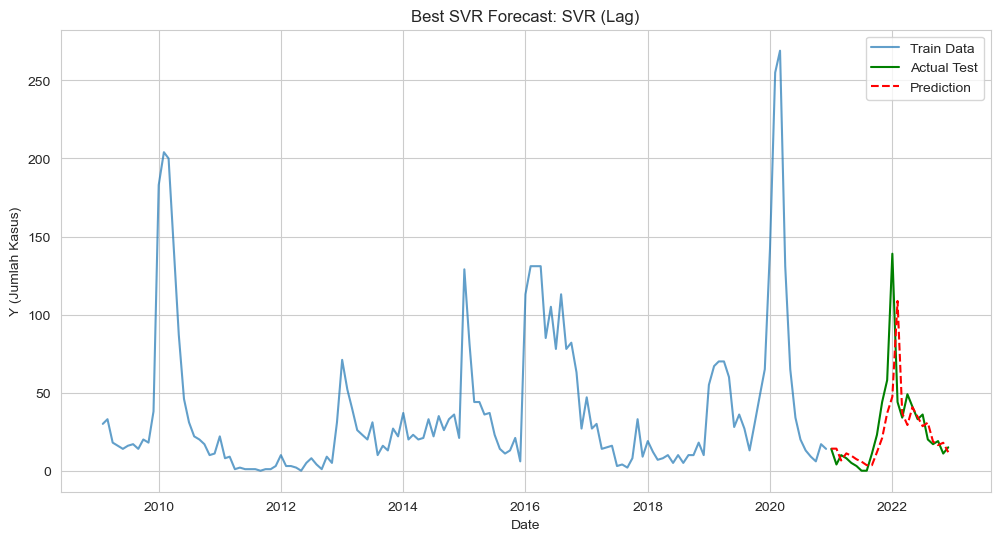

In [4]:
# Parameter Grid untuk SVR
param_grid = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__gamma': ['scale', 'auto'],
    'svr__epsilon': [0.1, 1, 5],
    'svr__kernel': ['rbf', 'linear']
}

# Skenario Fitur
scenarios = {
    'SVR (X1)': ['X1'],
    'SVR (X2)': ['X2'],
    'SVR (X1+X2)': ['X1', 'X2'],
    'SVR (Lag)': ['Y_lag1']
}

best_svr_results = []
best_svr_model = None
best_svr_score = -np.inf

print("=== Memulai Grid Search SVR ===\n")

for name, features in scenarios.items():
    X_train = train[features]
    y_train = train['Y']
    X_test = test[features]
    y_test = test['Y']
    
    # Pipeline: Scaling -> SVR
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ])
    
    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # Prediksi & Evaluasi
    y_pred = grid.predict(X_test)
    metrics = evaluate_model(y_test, y_pred, name)
    best_svr_results.append(metrics)
    
    # Simpan model terbaik berdasarkan R2
    if metrics['R2'] > best_svr_score:
        best_svr_score = metrics['R2']
        best_svr_model = {
            'name': name,
            'y_pred': y_pred,
            'params': grid.best_params_
        }

print(f"Best SVR Scenario: {best_svr_model['name']}")
print(f"Best Params: {best_svr_model['params']}")

# Plot SVR Terbaik
plot_forecast(train['Date'], train['Y'], test['Date'], test['Y'], best_svr_model['y_pred'], f"Best SVR Forecast: {best_svr_model['name']}")

## ARIMA Modeling

=== Analisis ARIMA ===

ADF Statistic: -3.3748
p-value: 0.0119
Data stasioner (Tolak H0)

Mencari model ARIMA terbaik...
Best ARIMA Order: (2, 0, 0)
--- ARIMA Performance ---
RMSE : 29.2401
MAE  : 21.5319
R2   : -0.0429
MAPE : 1405683770247117312.0000%



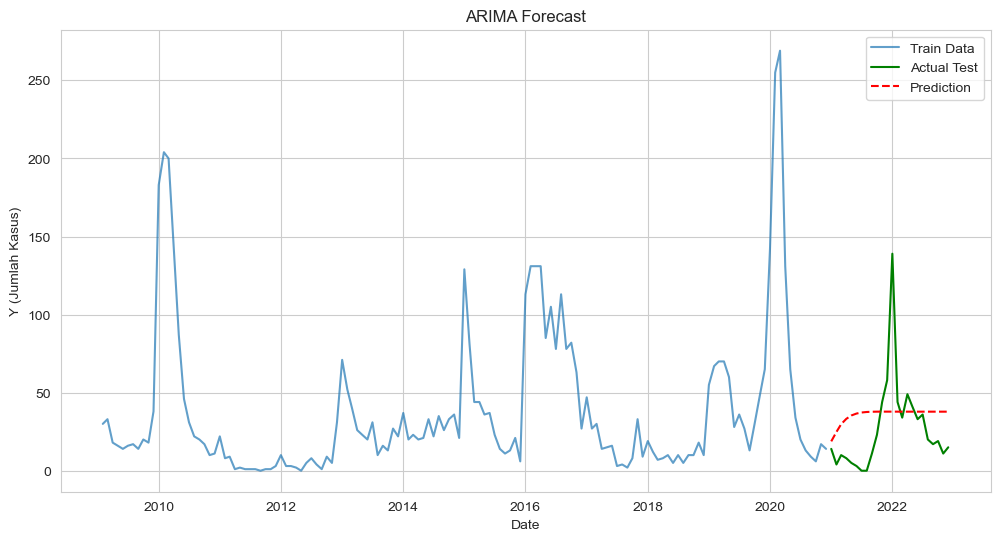

In [5]:
print("=== Analisis ARIMA ===\n")

# 1. Cek Stasioneritas
check_stationarity(train['Y'])

# 2. Auto ARIMA (Mencari order terbaik p,d,q secara otomatis)
print("\nMencari model ARIMA terbaik...")
arima_model = auto_arima(train['Y'], seasonal=False, stepwise=True, trace=False, suppress_warnings=True)
print(f"Best ARIMA Order: {arima_model.order}")

# 3. Fitting & Prediksi
arima_model.fit(train['Y'])
y_pred_arima = arima_model.predict(n_periods=len(test))

# 4. Evaluasi & Plot
arima_metrics = evaluate_model(test['Y'], y_pred_arima, "ARIMA")
plot_forecast(train['Date'], train['Y'], test['Date'], test['Y'], y_pred_arima, "ARIMA Forecast")

## Kesimpulan & Perbandingan

=== Perbandingan Akhir ===


,RMSE,MAE,R2,MAPE
Model,,,,
SVR (Lag),24.650310,12.970721,0.258821,1.754779e+17
SVR (X1+X2),26.901946,19.396635,0.117234,6.166175e+17
SVR (X2),26.946658,19.239582,0.114297,6.098625e+17
SVR (X1),27.222536,18.296588,0.096069,5.839127e+17
ARIMA,29.240074,21.531908,-0.042882,1.405684e+18


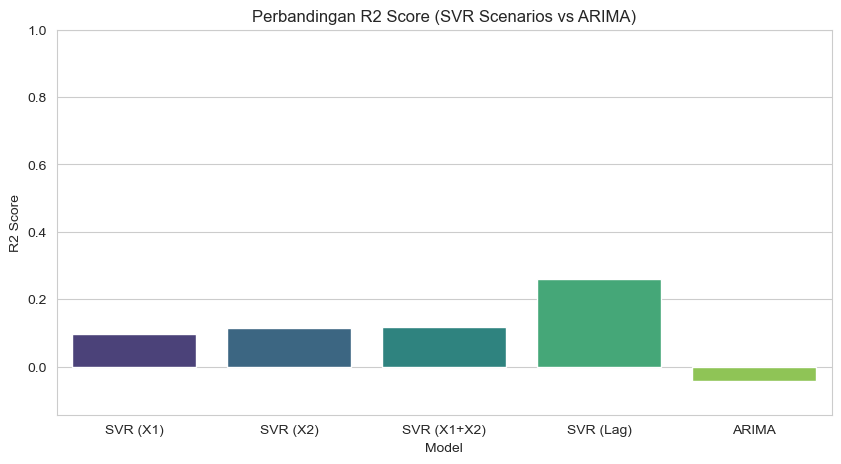

Kesimpulan: Berdasarkan metrik R-Squared, model terbaik adalah SVR (Lag).
Catatan: Nilai R2 masih di bawah 0.5, mengindikasikan bahwa fitur yang digunakan mungkin belum cukup kuat untuk memprediksi Y, atau data memiliki volatilitas tinggi yang sulit ditangkap model ini.


In [6]:
# Kompilasi Hasil
results_df = pd.DataFrame(best_svr_results)
results_df = results_df._append(arima_metrics, ignore_index=True)
results_df.set_index('Model', inplace=True)

print("=== Perbandingan Akhir ===")
display(results_df.sort_values(by='R2', ascending=False))

# Visualisasi Bar Chart untuk R2
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df['R2'], palette='viridis')
plt.title('Perbandingan R2 Score (SVR Scenarios vs ARIMA)')
plt.ylabel('R2 Score')
plt.ylim(bottom=min(results_df['R2']) - 0.1, top=1.0)
plt.show()

# Kesimpulan Teks
best_model_name = results_df['R2'].idxmax()
print(f"Kesimpulan: Berdasarkan metrik R-Squared, model terbaik adalah {best_model_name}.")
if results_df.loc[best_model_name, 'R2'] < 0.5:
    print("Catatan: Nilai R2 masih di bawah 0.5, mengindikasikan bahwa fitur yang digunakan mungkin belum cukup kuat untuk memprediksi Y, atau data memiliki volatilitas tinggi yang sulit ditangkap model ini.")